In [ ]:
%%capture

import time
import random
from copy import copy
import tqdm
import os
import pickle

try:
    from juliacall import Main as jl
except:
    !pip install juliacall
    from juliacall import Main as jl

try:
    import numpyro
except:
    !pip install numpyro
    import numpyro

numpyro.set_host_device_count(4)

import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, SVI, Trace_ELBO, Predictive
import jax
import jax.numpy as jnp
import jax.scipy.stats as jstats
from jax.scipy.special import logsumexp
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.special import softmax
from scipy.stats import wasserstein_distance

DEBUG_PRINTS = False

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Base directory
BASE_DIR = '/content/drive/MyDrive/thesis-pomdp-inference/'
LASERTAG_DIR = f'{BASE_DIR}/lasertag/'
JULIA_ENV_DIR = f'{BASE_DIR}/julia_env/'

os.makedirs(JULIA_ENV_DIR, exist_ok=True)
os.makedirs(LASERTAG_DIR, exist_ok=True)
os.makedirs(f'{LASERTAG_DIR}/inference/', exist_ok=True)
os.makedirs(f'{LASERTAG_DIR}/experiments/', exist_ok=True)

print(f"LaserTag directory ready: {LASERTAG_DIR}")

Mounted at /content/drive
LaserTag directory ready: /content/drive/MyDrive/thesis-pomdp-inference//lasertag/


In [ ]:
def save_data(filename, data, subdir='', show_prints=True):
    """Save data to Drive with subdirectory support"""
    save_dir = f'{LASERTAG_DIR}{subdir}/'
    os.makedirs(save_dir, exist_ok=True)

    filepath = f'{save_dir}{filename}.pkl'
    with open(filepath, 'wb') as f:
        pickle.dump(data, f)

    if show_prints:
        print(f"Saved: {filename}")

def load_data(filename, subdir='', show_prints=True):
    """Load data from Drive"""
    filepath = f'{LASERTAG_DIR}{subdir}/{filename}.pkl'
    if os.path.exists(filepath):
        with open(filepath, 'rb') as f:
            data = pickle.load(f)
        if show_prints:
            print(f"Loaded: {filename}")
        return data
    else:
        if show_prints:
            print(f"Not found: {filename}")
        return None

def file_exists(filename, subdir='', show_prints=True):
    """Check if file exists"""
    filepath = f'{LASERTAG_DIR}{subdir}/{filename}.pkl'
    file_exists = os.path.exists(filepath)
    if show_prints:
        if file_exists:
            print(f"{filename} exists")
        else:
            print(f"{filename} does not exist")
    return file_exists

## LaserTag POMDP

The LaserTag POMDP problem is a classic Partially Observable Markov decision process that models a robot equipped with a laser sensor attempting to tag an opponent in a grid environment. This problem tests the robot's ability to track and intercept a moving target while dealing with noisy sensor observations.

#### Problem Description

- **States**:
  - The state space consists of the **robot's position**, the **opponent's position** on a grid, and a **terminal flag** indicating whether the game has ended. For example, a state might represent the robot at position `(x₁, y₁)`, the opponent at position `(x₂, y₂)`, and whether the episode is complete.

- **Actions**:
  - There are **4 basic movement actions**: north, south, east, west that move the robot one cell in the corresponding direction.
  - Additionally, there is a **tag action** that attempts to tag the opponent when they are in the same cell as the robot.
  - **Total**: 5 actions (4 movement + 1 tag).

- **Transition Model**:
  - **Robot movement**: The robot moves deterministically in the direction of the selected action. If the robot attempts to move into an obstacle or beyond the grid boundary, it remains in its current position.
  - **Opponent behavior**: The opponent moves according to a stochastic policy that attempts to avoid the robot. With 40% probability each, the opponent moves toward/away from the robot in the x and y directions, and with the remaining probability stays in place. The opponent cannot move through obstacles.
  - **Terminal condition**: The episode ends when the robot successfully tags the opponent (both occupy the same cell and tag action is executed).

- **Observation Model**:
  - The robot is equipped with a **laser sensor** that measures distances in **8 directions** (4 cardinal + 4 diagonal directions) from its current position.
  - Each laser measurement reports the **number of clear cells** until hitting an obstacle, wall, or the opponent.
  - The laser measurements are corrupted by **Gaussian noise** with standard deviation `std`. The noise follows a half-normal distribution (always reduces the measured distance).
  - The noise parameter `std` controls the **laser variance** - this is the key parameter we want to infer through Bayesian estimation.
  - When the robot and opponent are in the same location, a special observation is returned.

- **Reward Model**:
  - The robot incurs a **step cost** (negative reward) for every movement action.
  - **Successful tagging**: When the robot executes the tag action while in the same cell as the opponent, it receives a large **positive reward** (`tag_reward`).
  - **Failed tagging**: When the robot executes the tag action while not in the same cell as the opponent, it receives a large **negative penalty** (`-tag_reward`).
  - The step cost is applied regardless of the action type, encouraging the robot to complete the task quickly.

#### Objective

The goal is to **minimize the expected time to tag the opponent** while dealing with:
- **Partial observability**: The robot can only observe laser distance measurements, not the opponent's exact position.
- **Noisy observations**: The laser measurements contain noise, making it difficult to precisely locate the opponent.
- **Moving target**: The opponent actively tries to avoid being tagged, making the task more challenging.
- **Unknown noise level**: The true laser variance is unknown and must be inferred from interaction data.

The robot must balance exploration (gathering information about the opponent's location through laser measurements) with exploitation (moving toward the estimated opponent position for tagging). The uncertainty in laser measurements and the opponent's evasive behavior create a complex decision-making problem that requires sophisticated POMDP planning algorithms.

### Parameter Inference
In our Bayesian framework, we focus on inferring the **laser variance** parameter from observed robot-environment interactions, allowing for more accurate POMDP policies that properly account for sensor uncertainty.

# LaserTag POMDP: Bayesian Parameter Learning Case Study

## Objective

This experiment validates that Bayesian parameter inference can improve POMDP policy performance when model parameters are initially misspecified. We focus on learning the laser sensor noise parameter (laser_std) in the LaserTag environment, demonstrating the practical importance of accurate parameter specification for deployed POMDP systems.

## Experimental Setup

We use the LaserTag POMDP where a robot attempts to tag a moving opponent using noisy laser distance measurements. The key parameter is laser_std, which controls the Gaussian noise in sensor observations and significantly impacts the policy's belief state updates and decision-making.

The experiment follows a three-stage process. First, we generate a policy using an incorrect laser_std value and deploy it in the true environment, recording poor performance due to parameter misspecification. Second, we collect trajectory data from this deployment and use Bayesian inference to estimate the true laser_std parameter from the observed state-action-observation sequences. Third, we retrain the policy using the inferred parameter and demonstrate improved performance when deployed in the true environment.

## Hypothesis

A policy trained with incorrect sensor noise parameters will perform poorly in the true environment, but retraining with Bayesian-inferred parameters will recover most of the performance loss compared to an oracle policy trained with true parameters.

## Evaluation Metrics

We measure performance recovery as (Reward_improved - Reward_wrong) / (Reward_oracle - Reward_wrong), parameter estimation accuracy as the relative error between inferred and true values, and statistical significance across multiple experimental runs. Success is demonstrated by significant performance improvement and accurate parameter recovery using realistic amounts of interaction data.

## Implementation

The framework integrates JuliaPOMDP for policy generation, juliacall for Julia-Python interoperability in Colab, and NumPyro for Bayesian inference. We implement a generative model $P(\text{observations | laser_std, states, actions})$ that captures the sensor noise process, then use MCMC sampling to estimate the posterior distribution over laser_std given observed trajectory data.

In [ ]:
print("Installing Julia packages...")

jl.Pkg.add('POMDPs')
jl.Pkg.add(url="https://github.com/JuliaPOMDP/LaserTag.jl.git")
jl.Pkg.add('QMDP')
jl.Pkg.add('POMDPTools')
jl.Pkg.add('ParticleFilters')

print("Julia packages installed successfully!")

Installing Julia packages...
Julia packages installed successfully!


## Policy Generation Function

This function creates a QMDP policy for the LaserTag environment with a specified laser sensor noise parameter (laser_std). This allows us to train policies with different assumptions about sensor accuracy.

In [ ]:
def generate_policy(pomdp):
    """Generate a QMDP policy for given LaserTag POMDP"""
    if DEBUG_PRINTS:
        print("Generating policy for provided POMDP...")

    try:
        jl.training_pomdp = pomdp

        jl.seval(f"""
        using POMDPs, QMDP

        # Solve with QMDP on the provided POMDP
        solver = QMDPSolver(verbose=false)
        policy = solve(solver, training_pomdp)
        """)

        return jl.policy

    except Exception as e:
        if DEBUG_PRINTS:
            print(f"Policy generation failed: {e}")
        return None

In [ ]:
def create_pomdp_environment(laser_std, random_seed=123):
    """Create LaserTag POMDP environment with specified laser_std"""
    if DEBUG_PRINTS:
        print(f"Creating environment with laser_std={laser_std}...")

    try:
        jl.seval(f"""
        using POMDPs, LaserTag, Random

        # Set random seed for deterministic environment creation
        Random.seed!({random_seed})

        obs_model = LaserTag.DESPOTEmu(LaserTag.Floor(7, 11), {laser_std})
        pomdp_env = gen_lasertag(7, 11,
                                obstacles=Set{{LaserTag.Coord}}(),
                                obs_model=obs_model,
                                robot_position_known=true)
        """)

        print("Environment created successfully")
        return jl.pomdp_env

    except Exception as e:
        if DEBUG_PRINTS:
            print(f"Environment creation failed: {e}")
        return None

## Policy Testing Function

This function tests a policy in an environment with the TRUE laser_std parameter, simulating real-world deployment. It collects trajectory data (states, actions, observations, rewards) that we'll use for Bayesian inference.

In [ ]:
def test_policy(policy, pomdp, belief_pomdp=None, n_episodes=10, max_steps=100, random_seed=1000):
    """
    Test a policy on true environment with belief updates

    Args:
        policy: The policy to test
        pomdp: The TRUE environment to test in
        belief_pomdp: The POMDP model used for belief updates (if None, uses true environment)
        n_episodes: Number of episodes
        max_steps: Max steps per episode
        random_seed: Base random seed - each episode uses random_seed + episode_number
    """
    if DEBUG_PRINTS:
        print(f"Testing policy for {n_episodes} episodes...")

    try:
        jl.test_policy = policy
        jl.true_env_pomdp = pomdp  # true environment for simulation
        jl.belief_pomdp = belief_pomdp if belief_pomdp is not None else pomdp  # model for beliefs
        jl.n_eps = n_episodes
        jl.max_steps = max_steps
        jl.base_seed = random_seed

        jl.seval(f"""
        using POMDPs, POMDPTools, ParticleFilters, Statistics, Random

        episode_rewards = Float64[]
        all_trajectories = []

        # Create particle filter for belief updates
        updater = BootstrapFilter(belief_pomdp, 10000)

        for ep in 1:n_eps
            # Set different seed for each episode: base_seed + episode_number
            episode_seed = base_seed + ep - 1
            Random.seed!(episode_seed)

            # Initialize from TRUE environment
            s = rand(initialstate(true_env_pomdp))

            # Initialize belief using the belief model (potentially wrong model)
            b0 = initialstate(belief_pomdp)
            b = initialize_belief(updater, b0)

            episode_reward = 0.0
            step = 0

            traj_states = []
            traj_actions = []
            traj_observations = []
            traj_rewards = []

            while !isterminal(true_env_pomdp, s) && step < max_steps
                # Get action based on (potentially wrong) beliefs
                a = action(test_policy, b)

                # Generate observation from TRUE environment
                sp, o, r = @gen(:sp, :o, :r)(true_env_pomdp, s, a)

                # Update belief using the belief model (which may be wrong!)
                try
                    b = update(updater, b, a, o)
                catch e
                    # If update fails, just keep previous belief
                    # This handles terminal particle issues more gracefully
                end

                push!(traj_states, s)
                push!(traj_actions, a)
                push!(traj_observations, o)
                push!(traj_rewards, r)

                episode_reward += r
                s = sp
                step += 1
            end

            push!(episode_rewards, episode_reward)
            push!(all_trajectories, Dict(
                "states" => traj_states,
                "actions" => traj_actions,
                "observations" => traj_observations,
                "rewards" => traj_rewards
            ))
        end
        """)

        return jl.all_trajectories

    except Exception as e:
        if DEBUG_PRINTS:
            print(f"Policy testing failed: {e}")
        return None

## Validation: Smoke Test

Before proceeding with Bayesian inference, let's validate our experimental setup by comparing two policies: one trained with wrong parameters and one trained with correct parameters. Both will be tested in the true environment. This "smoke test" confirms that parameter misspecification actually hurts performance, validating the foundation of our experiment.

In [ ]:
N_EPISODES = 1000
RANDOM_SEED = 7
SIM_LASER_STD = 10.0
TRUE_LASER_STD = 2.5

needs_regeneration = True
DEBUG_PRINTS = True
if file_exists('sim_trajectories', subdir='data') and file_exists('true_trajectories', subdir='data'):
    sim_trajectories = load_data('sim_trajectories', subdir='data')
    true_trajectories = load_data('true_trajectories', subdir='data')

    if (sim_trajectories and true_trajectories and
        sim_trajectories.get('n_episodes') == N_EPISODES and
        sim_trajectories.get('random_seed') == RANDOM_SEED and
        sim_trajectories.get('laser_std') == SIM_LASER_STD):
        needs_regeneration = False
        print("Loaded existing trajectories")

if needs_regeneration:
    print("Generating new trajectories...")

    sim_pomdp = create_pomdp_environment(laser_std=SIM_LASER_STD, random_seed=123)
    true_pomdp = create_pomdp_environment(laser_std=TRUE_LASER_STD, random_seed=123)

    sim_policy = generate_policy(sim_pomdp)
    true_policy = generate_policy(true_pomdp)

    sim_traj_julia = test_policy(
        sim_policy, pomdp=true_pomdp, belief_pomdp=sim_pomdp,
        n_episodes=N_EPISODES, random_seed=RANDOM_SEED
    )
    true_traj_julia = test_policy(
        true_policy, pomdp=true_pomdp, belief_pomdp=true_pomdp,
        n_episodes=N_EPISODES, random_seed=RANDOM_SEED
    )

    sim_traj_list = [dict(traj) for traj in sim_traj_julia]
    true_traj_list = [dict(traj) for traj in true_traj_julia]

    def julia_to_python(traj_dict):
        # Convert states from Julia objects to Python tuples
        python_states = []
        for s in traj_dict['states']:
            # Extract robot, opponent, terminal from Julia LTState object
            robot = (int(s.robot[0]), int(s.robot[1]))
            opponent = (int(s.opponent[0]), int(s.opponent[1]))
            terminal = bool(s.terminal)
            python_states.append((robot, opponent, terminal))

        return {
            'states': python_states,
            'actions': [int(a) for a in traj_dict['actions']],
            'observations': [list(o) if hasattr(o, '__iter__') else o for o in traj_dict['observations']],
            'rewards': [float(r) for r in traj_dict['rewards']]
        }

    sim_traj_python = [julia_to_python(t) for t in sim_traj_list]
    true_traj_python = [julia_to_python(t) for t in true_traj_list]

    sim_trajectories = {
        'trajectories': sim_traj_python,
        'n_episodes': N_EPISODES,
        'random_seed': RANDOM_SEED,
        'laser_std': SIM_LASER_STD,
        'true_laser_std': TRUE_LASER_STD
    }

    true_trajectories = {
        'trajectories': true_traj_python,
        'n_episodes': N_EPISODES,
        'random_seed': RANDOM_SEED,
        'laser_std': TRUE_LASER_STD
    }

    save_data('sim_trajectories', sim_trajectories, subdir='data')
    save_data('true_trajectories', true_trajectories, subdir='data')

print(f"Sim trajectories: {len(sim_trajectories['trajectories'])} (laser_std={sim_trajectories['laser_std']})")
print(f"True trajectories: {len(true_trajectories['trajectories'])} (laser_std={true_trajectories['laser_std']})")

sim_trajectories exists
true_trajectories exists
Loaded: sim_trajectories
Loaded: true_trajectories
Loaded existing trajectories
Sim trajectories: 1000 (laser_std=10.0)
True trajectories: 1000 (laser_std=2.5)


/tmp/ipython-input-1369325014.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(box_data, labels=labels, patch_artist=True,


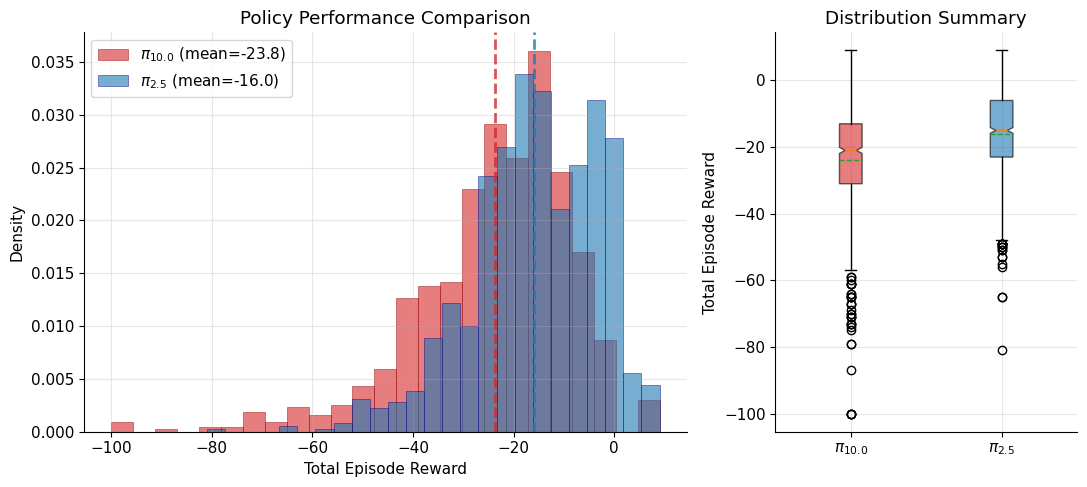

POLICY EVALUATION RESULTS
Episodes per policy: 1,000

Policy trained with laser_std=10.0:
  Mean reward: -23.76 +/- 15.52
  Median reward: -21.00

Policy trained with laser_std=2.5:
  Mean reward: -15.99 +/- 12.60
  Median reward: -15.00

Performance Gap:
  Difference: 7.77 (+32.7%)


In [ ]:
sim_rewards = [sum(ep['rewards']) for ep in sim_trajectories['trajectories'] if ep is not None]
real_rewards = [sum(ep['rewards']) for ep in true_trajectories['trajectories'] if ep is not None]

plt.rcParams.update({'font.size': 11, 'axes.grid': True, 'grid.alpha': 0.3})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5), gridspec_kw={'width_ratios': [2.0, 1.0]})

sim_rewards_np = np.array(sim_rewards)
real_rewards_np = np.array(real_rewards)
sim_mean, sim_std = np.mean(sim_rewards_np), np.std(sim_rewards_np)
real_mean, real_std = np.mean(real_rewards_np), np.std(real_rewards_np)

ax1.hist(sim_rewards_np, bins=25, alpha=0.6, density=True,
         label=rf'$\pi_{{10.0}}$ (mean={sim_mean:.1f})',
         color='#d62728', edgecolor='darkred', linewidth=0.5)
ax1.hist(real_rewards_np, bins=25, alpha=0.6, density=True,
         label=rf'$\pi_{{2.5}}$ (mean={real_mean:.1f})',
         color='#1f77b4', edgecolor='darkblue', linewidth=0.5)

ax1.axvline(sim_mean, color='#d62728', linewidth=2, linestyle='--', alpha=0.8)
ax1.axvline(real_mean, color='#1f77b4', linewidth=2, linestyle='--', alpha=0.8)

ax1.set_xlabel('Total Episode Reward')
ax1.set_ylabel('Density')
ax1.set_title('Policy Performance Comparison')
ax1.legend(loc='best')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

box_data = [sim_rewards_np, real_rewards_np]
labels = [r'$\pi_{10.0}$', r'$\pi_{2.5}$']

bp = ax2.boxplot(box_data, labels=labels, patch_artist=True,
                 notch=True, showmeans=True, meanline=True)

bp['boxes'][0].set_facecolor('#d62728')
bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('#1f77b4')
bp['boxes'][1].set_alpha(0.6)

ax2.set_ylabel('Total Episode Reward')
ax2.set_title('Distribution Summary')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print("=" * 50)
print("POLICY EVALUATION RESULTS")
print("=" * 50)
print(f"Episodes per policy: {len(sim_rewards_np):,}")
print(f"\nPolicy trained with laser_std=10.0:")
print(f"  Mean reward: {sim_mean:.2f} +/- {sim_std:.2f}")
print(f"  Median reward: {np.median(sim_rewards_np):.2f}")
print(f"\nPolicy trained with laser_std=2.5:")
print(f"  Mean reward: {real_mean:.2f} +/- {real_std:.2f}")
print(f"  Median reward: {np.median(real_rewards_np):.2f}")
print(f"\nPerformance Gap:")
print(f"  Difference: {real_mean - sim_mean:.2f} ({((real_mean - sim_mean)/abs(sim_mean)*100):+.1f}%)")
print("=" * 50)

In [ ]:
def extract_trajectories_data(trajectories, pomdp):
    """
    Extract trajectory data with correct temporal alignment

    Trajectory collection produces:
    - states[i] = state at time i
    - observations[i] = observation of states[i+1]

    We align by keeping all states and using None for missing observations:
    - states[0] with observations[0] = None (no observation of initial state)
    - states[i] with observations[i-1] for i > 0
    """

    # extract obstacles from the provided POMDP
    jl.temp_pomdp = pomdp
    jl.seval("obstacles_list = collect(temp_pomdp.obstacles)")
    obstacles = [(int(obs[0]), int(obs[1])) for obs in jl.obstacles_list]

    episodes = []

    # extract data from each trajectory (each trajectory = one episode)
    for traj_idx, traj in enumerate(trajectories):
        states = traj['states']  # Now a dict, not Julia object
        actions = traj['actions']
        observations = traj['observations']
        rewards = traj['rewards']

        episode_observations = []
        episode_states = []
        episode_actions = []
        episode_rewards = []

        for step in range(len(states)):
            # States are already Python tuples: (robot_pos, opponent_pos, terminal)
            parsed_state = states[step]
            episode_states.append(parsed_state)

            # align observations: obs[i-1] corresponds to states[i]
            if step == 0:
                episode_observations.append(None)
            else:
                episode_observations.append(list(observations[step - 1]))

            if step < len(actions):
                episode_actions.append(actions[step])
            if step < len(rewards):
                episode_rewards.append(rewards[step])

        episodes.append({
            'observations': episode_observations,
            'states': episode_states,
            'actions': episode_actions,
            'rewards': episode_rewards
        })

    inference_data = {
        'episodes': episodes,
        'obstacles': obstacles,
        'n_episodes': len(episodes),
        'n_total_steps': sum(len(ep['observations']) for ep in episodes)
    }

    return inference_data

In [ ]:
N_DATA = 15

needs_regeneration = False
if file_exists('lasertag_data', subdir='data'):
    lasertag_data = load_data('lasertag_data', subdir='data')

    if lasertag_data.get('n_data_episodes', None) != N_DATA:
        print(f"N_DATA mismatch: saved={lasertag_data.get('n_data_episodes', None)}, current={N_DATA}")
        print("Regenerating data...")
        needs_regeneration = True
else:
    needs_regeneration = True

if needs_regeneration:
    lasertag_data = extract_trajectories_data(sim_trajectories['trajectories'][:N_DATA], true_pomdp)
    lasertag_data['n_data_episodes'] = N_DATA
    lasertag_data['true_laser_std'] = 2.5
    lasertag_data['sim_laser_std'] = 10.0
    save_data('lasertag_data', lasertag_data, subdir='data')

print(f"\nN_DATA: {lasertag_data['n_data_episodes']}")
print(f"Episodes: {lasertag_data['n_episodes']}")
print(f"Total steps: {lasertag_data['n_total_steps']}")

lasertag_data exists
Loaded: lasertag_data

N_DATA: 15
Episodes: 15
Total steps: 374


## Data Format

**POMDP Trajectory Structure:**

A POMDP trajectory consists of sequences $(s_t, a_t, o_t, r_t)_{t=0}^T$ where:
- $s_t \in S$ = state at time $t$
- $a_t \in A$ = action taken at time $t$
- $o_t \in O$ = observation received at time $t$
- $r_t \in R$ = reward received at time $t$

**Temporal Causality:**

The standard POMDP generative process follows:
$$s_0 \xrightarrow{a_0} s_1 \xrightarrow{a_1} s_2 \xrightarrow{a_2} s_3 \xrightarrow{a_3} \cdots$$

With observations generated as:
$$o_t \sim O(s_{t+1}) \quad \text{where } o_t \text{ is observed after transitioning to } s_{t+1}$$

**Data Alignment:**

Trajectory collection via `@gen(:sp, :o, :r)` produces:
- `states = [s₀, s₁, s₂, s₃, s₄]`
- `observations = [o₀, o₁, o₂, o₃]` where $o_i$ is the observation of $s_{i+1}$

**Correct Temporal Alignment:**

To ensure $\text{observations}[i]$ corresponds to $\text{states}[i]$:

```
states[0] = s₀  →  observations[0] = None     (no observation of initial state)
states[1] = s₁  →  observations[1] = o₀       (o₀ is observation of s₁)  
states[2] = s₂  →  observations[2] = o₁       (o₁ is observation of s₂)
states[3] = s₃  →  observations[3] = o₂       (o₂ is observation of s₃)
states[4] = s₄  →  observations[4] = o₃       (o₃ is observation of s₄)
```

**Likelihood Calculation:**

For parameter inference, we skip entries where `observations[i] is None`:

$$L(\theta) = \prod_{\substack{i=1 \\ \text{obs}[i] \neq \text{None}}}^{T} p(\text{observations}[i] | \text{states}[i], \theta)$$

Where $p(\text{observations}[i] | \text{states}[i], \theta)$ represents the LaserTag observation model with parameter $\theta$ (laser noise standard deviation), evaluated at the state-observation pair.

In [ ]:
def logprob_laser_episode(laser_std, episode_states, episode_observations):
    """
    LaserTag logprob calculation per episode.
    observed <= true_distance always, with abs_noise ~ HalfNormal(laser_std)
    """
    directions = [(0, 1), (1, 0), (0, -1), (-1, 0), (1, 1), (1, -1), (-1, -1), (-1, 1)]

    # collect all data for vectorized computation
    all_true_distances = []
    all_observed = []
    grid = (11, 7)

    for step in range(len(episode_states)):
        robot_pos, opponent_pos, terminal = episode_states[step]
        if terminal:
            break

        observed_distances = episode_observations[step]

        if robot_pos == opponent_pos:
            continue

        if observed_distances is None or np.any(np.array(observed_distances) < 0):
            continue

        for direction_idx, (dx, dy) in enumerate(directions):
            # Calculate clear cells
            distance = 0
            x, y = robot_pos
            while True:
                x += dx
                y += dy
                distance += 1
                if x < 1 or x > grid[0] or y < 1 or y > grid[1]:
                    break
                if (x, y) == opponent_pos:
                    break

            clear_cells = distance - 1
            observed_distance = observed_distances[direction_idx]

            # Calculate "true processed distance" as in LaserTag
            if direction_idx < 4:  # Cardinal
                true_distance = clear_cells + 1
            else:  # in the diagonal, we talk the Euclidean distance, which is (true_distance + 1) * sqrt(2) (assuming a cell has has size 1x1, the diagonal length is sqrt(2))
                true_distance = (clear_cells + 1) * jnp.sqrt(2)

            all_true_distances.append(true_distance)
            all_observed.append(observed_distance)

    all_true_distances = jnp.array(all_true_distances)
    all_observed = jnp.array(all_observed)

    # abs_noise ~ HalfNormal(laser_std)
    # abs_noise = true_distance - observed
    abs_noise_values = all_true_distances - all_observed

    # calculate log probability using HalfNormal distribution
    half_normal_logprobs = dist.HalfNormal(laser_std).log_prob(abs_noise_values)
    total_logp = jnp.sum(half_normal_logprobs)

    return total_logp

def model(data):
    """Bayesian model for laser_std inference"""
    laser_std = numpyro.sample('laser_std', dist.Exponential(0.2))

    for iepisode, episode in enumerate(data['episodes']):
        states = episode['states']
        observations = episode['observations']
        episode_logp = logprob_laser_episode(laser_std, states, observations)
        numpyro.factor(f'episode_{iepisode}', episode_logp)

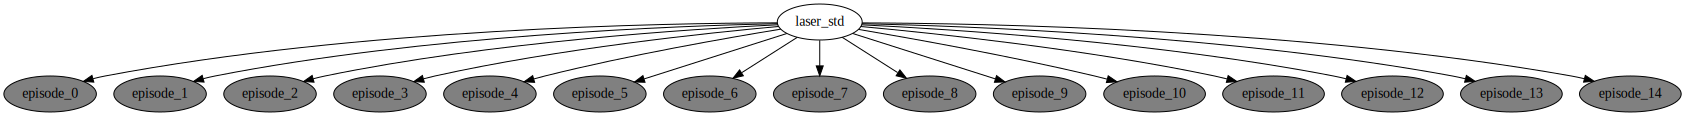

In [ ]:
numpyro.render_model(model, model_args=(lasertag_data,))

In [ ]:
def run_inference(model, data, num_warmup=1000, num_samples=5000):
    nuts_kernel = NUTS(model)
    mcmc = MCMC(nuts_kernel, num_warmup=num_warmup, num_samples=num_samples, num_chains=2)

    rng_key = jax.random.PRNGKey(int(time.time() * 1E6))
    mcmc.run(rng_key, data)

    return mcmc

In [ ]:
print("Running MCMC inference...")
mcmc = run_inference(model, lasertag_data, num_warmup=1000, num_samples=10000)

mcmc_samples = mcmc.get_samples()
mcmc_laser_std_samples = np.array(mcmc_samples['laser_std'])

mcmc.print_summary()

Running MCMC inference...


  0%|          | 0/11000 [00:00<?, ?it/s]

  0%|          | 0/11000 [00:00<?, ?it/s]


                 mean       std    median      5.0%     95.0%     n_eff     r_hat
  laser_std      2.47      0.03      2.47      2.41      2.52   6264.96      1.00

Number of divergences: 0


In [ ]:
def plot_inference_results(laser_std_samples, actual_laser_std=2.5):
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.hist(laser_std_samples, bins='auto', alpha=0.7, density=True)
    plt.axvline(actual_laser_std, color='red', label=f'actual laser_std: {actual_laser_std}')
    plt.axvline(np.mean(laser_std_samples), color='green', label=f'MCMC Mean: {np.mean(laser_std_samples):.2f}')
    plt.xlabel('laser_std')
    plt.title('Posterior')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(laser_std_samples)
    plt.axhline(actual_laser_std, color='red', label=f'actual laser_std: {actual_laser_std}')
    plt.xlabel('Sample')
    plt.title('Trace')
    plt.legend()

    plt.tight_layout()
    plt.show()

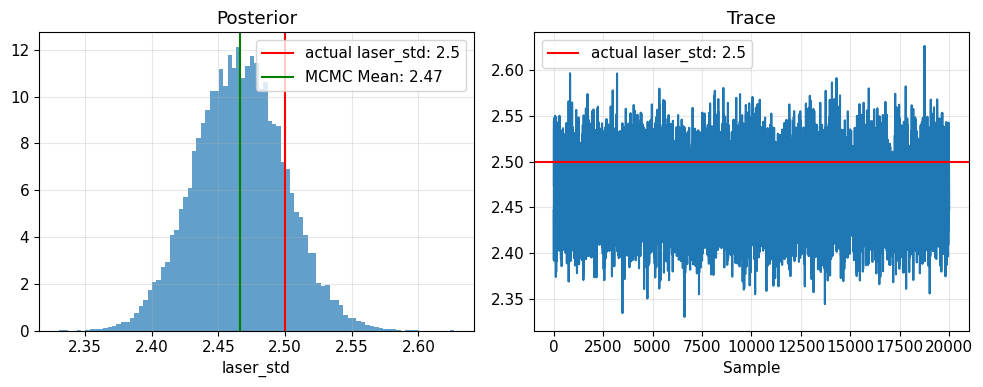

In [ ]:
plot_inference_results(mcmc_laser_std_samples, actual_laser_std=2.5)

# LaserTag SVI: Learning Sensor Parameters with Unknown Robot Positions

In the JuliaPOMDP LaserTag framework, we don't have access to modify the transition model to add stochasticity. However, we have laser distance observations that were recorded along with robot positions during deterministic episodes.

To test our SVI POMDP parameter learning algorithm, we want to "discard" the robot positions from the observations and learn the sensor noise parameter (`laser_std`) using only the laser measurements. We'll use a stochastic transition model to generate possible robot trajectories.

**Why this approach is theoretically correct:** Even though the original data came from deterministic movements, we can treat the robot positions as hidden states and use Bayesian inference to simultaneously estimate both the unknown trajectories and the sensor parameter. **The stochastic model represents our uncertainty about the robot's path, not the actual randomness that occurred.** The laser observations constrain which robot trajectories are more probable - trajectories that better explain the observed laser distances will get higher likelihood scores.

Through SVI, we'll sample many possible trajectories and let the laser observations tell us which ones (and which laser_std values) best explain the data.

## Removing Robot Positions from Observations

Since we want to test learning without knowing robot positions, we need to create a modified version of our data that only contains the laser distance measurements. We'll keep everything else (opponent positions, actions, rewards) but remove the robot positions from the state information.

This simulates a realistic scenario where we have sensor data and know our actions, but don't have perfect localization of our robot.

In [ ]:
def remove_opponent_positions(data):
    """Remove opponent positions from episodes (but keep robot positions)"""
    modified_episodes = []

    for episode in data['episodes']:
        modified_states = []

        for i, state in enumerate(episode['states']):
            robot_pos, opponent_pos, terminal = state
            if i == 0:
                # Keep initial opponent position - we need to know where they start
                modified_state = (robot_pos, opponent_pos, terminal)
            else:
                # Remove opponent position from subsequent states - this is what we'll infer
                modified_state = (robot_pos, None, terminal)
            modified_states.append(modified_state)

        modified_episode = {
            'observations': episode['observations'],  # Keep laser measurements
            'states': modified_states,                # Robot positions kept, opponent removed
            'actions': episode['actions'],            # Keep actions
            'rewards': episode['rewards']             # Keep rewards
        }
        modified_episodes.append(modified_episode)

    return {
        'episodes': modified_episodes,
        'obstacles': data['obstacles'],
        'n_episodes': data['n_episodes'],
        'n_total_steps': data['n_total_steps']
    }

## Stochastic Transition Model

Since we don't know where the robot actually moved, we'll use a stochastic transition model to generate possible robot trajectories. We'll assume 80% chance the robot moves in the intended direction, and 10% chance for each perpendicular direction.

**The stochastic model represents our uncertainty about the robot's path, not the actual randomness that occurred.** We'll generate many possible trajectories and let the laser observations tell us which ones are more likely.

In [ ]:
def apply_stochastic_opponent_movement(robot_pos, prev_opponent_pos, obstacles=None):
    """
    Apply stochastic opponent movement based on LaserTag Julia implementation.

    Opponent behavior (AVOIDANCE):
    - 0.4 chance of moving away from robot in x direction (if not blocked)
    - 0.4 chance of moving away from robot in y direction (if not blocked)
    - 0.2 + blocked mass chance of staying in place
    """
    if obstacles is None:
        obstacles = set()

    # Grid boundaries
    grid_bounds = (11, 7)  # (width, height)

    # Cardinal directions: north, east, south, west
    cardinal_dirs = [(0, 1), (1, 0), (0, -1), (-1, 0)]

    # Initialize movement probabilities [north, east, south, west, stay]
    probs = [0.0, 0.0, 0.0, 0.0, 0.0]

    robot_x, robot_y = robot_pos
    opp_x, opp_y = prev_opponent_pos

    # 0.4 chance of moving in x direction (AVOIDANCE behavior - move away from robot)
    if opp_x == robot_x:
        # Equal distance, split probability
        # Check east (direction index 1)
        new_pos_east = (opp_x + 1, opp_y)
        if (new_pos_east[0] >= 1 and new_pos_east[0] <= grid_bounds[0] and
            new_pos_east[1] >= 1 and new_pos_east[1] <= grid_bounds[1] and
            new_pos_east not in obstacles):
            probs[1] += 0.2  # east

        # Check west (direction index 3)
        new_pos_west = (opp_x - 1, opp_y)
        if (new_pos_west[0] >= 1 and new_pos_west[0] <= grid_bounds[0] and
            new_pos_west[1] >= 1 and new_pos_west[1] <= grid_bounds[1] and
            new_pos_west not in obstacles):
            probs[3] += 0.2  # west

    elif opp_x > robot_x:
        # Move east away from robot (direction index 1)
        new_pos_east = (opp_x + 1, opp_y)
        if (new_pos_east[0] >= 1 and new_pos_east[0] <= grid_bounds[0] and
            new_pos_east[1] >= 1 and new_pos_east[1] <= grid_bounds[1] and
            new_pos_east not in obstacles):
            probs[1] += 0.4  # east

    elif opp_x < robot_x:
        # Move west away from robot (direction index 3)
        new_pos_west = (opp_x - 1, opp_y)
        if (new_pos_west[0] >= 1 and new_pos_west[0] <= grid_bounds[0] and
            new_pos_west[1] >= 1 and new_pos_west[1] <= grid_bounds[1] and
            new_pos_west not in obstacles):
            probs[3] += 0.4  # west

    # 0.4 chance of moving in y direction (AVOIDANCE behavior - move away from robot)
    if opp_y == robot_y:
        # Equal distance, split probability
        # Check north (direction index 0)
        new_pos_north = (opp_x, opp_y + 1)
        if (new_pos_north[0] >= 1 and new_pos_north[0] <= grid_bounds[0] and
            new_pos_north[1] >= 1 and new_pos_north[1] <= grid_bounds[1] and
            new_pos_north not in obstacles):
            probs[0] += 0.2  # north

        # Check south (direction index 2)
        new_pos_south = (opp_x, opp_y - 1)
        if (new_pos_south[0] >= 1 and new_pos_south[0] <= grid_bounds[0] and
            new_pos_south[1] >= 1 and new_pos_south[1] <= grid_bounds[1] and
            new_pos_south not in obstacles):
            probs[2] += 0.2  # south

    elif opp_y > robot_y:
        # Move north away from robot (direction index 0)
        new_pos_north = (opp_x, opp_y + 1)
        if (new_pos_north[0] >= 1 and new_pos_north[0] <= grid_bounds[0] and
            new_pos_north[1] >= 1 and new_pos_north[1] <= grid_bounds[1] and
            new_pos_north not in obstacles):
            probs[0] += 0.4  # north

    elif opp_y < robot_y:
        # Move south away from robot (direction index 2)
        new_pos_south = (opp_x, opp_y - 1)
        if (new_pos_south[0] >= 1 and new_pos_south[0] <= grid_bounds[0] and
            new_pos_south[1] >= 1 and new_pos_south[1] <= grid_bounds[1] and
            new_pos_south not in obstacles):
            probs[2] += 0.4  # south

    # Remaining probability goes to staying in place
    probs[4] = 1.0 - sum(probs[:4])

    # Sample movement based on probabilities using standard random
    choice_int = np.random.choice(5, p=probs)

    if choice_int == 4:  # stay in place
        return prev_opponent_pos
    else:
        # Move in chosen direction
        dx, dy = cardinal_dirs[choice_int]
        new_pos = (opp_x + dx, opp_y + dy)
        return new_pos

## Trajectory Generation

For each episode, we need to generate possible **complete state trajectories** (both robot and opponent positions) using our stochastic models. We'll take the initial positions and the sequence of actions, then simulate where both the robot and opponent might have actually moved.
**Robot movement**: Using our stochastic model with configurable success probability (e.g., 90% intended direction, 5% each perpendicular direction)

**Opponent movement**: Using the LaserTag transition model (40% toward robot in x-direction, 40% toward robot in y-direction, 20% staying in place)

This approach is crucial for **avoiding parameter bias.** When robot positions are different from the original data due to stochastic movement, the opponent positions must also be allowed to vary. Otherwise, the likelihood computation uses wrong robot-opponent distances, and the laser_std parameter gets inflated to compensate for these geometric errors.

We generate new complete trajectories each SVI step to explore different possibilities - this is key to avoiding gradient cancellation while maintaining the correct parameter relationships.

In [ ]:
def generate_trajectories(data):
    """
    Generate opponent trajectory realizations for all episodes.
    Robot positions are known (from data), opponent positions are sampled.
    """
    trajectories = []
    obstacles = set(data['obstacles'])

    for episode in data['episodes']:
        # Get initial positions from first state
        initial_robot_pos, initial_opponent_pos, _ = episode['states'][0]

        # The trajectory starts with the first state from the data
        trajectory = [episode['states'][0]]

        # Track current opponent position (robot positions come from data)
        current_opponent_pos = initial_opponent_pos

        for i in range(len(episode['states']) - 1):
            # Get robot position from original data (this is known)
            robot_pos = episode['states'][i + 1][0]
            terminal = episode['states'][i + 1][2]

            if not terminal:
                # Sample opponent movement based on robot position
                current_opponent_pos = apply_stochastic_opponent_movement(
                    robot_pos=robot_pos,
                    prev_opponent_pos=current_opponent_pos,
                    obstacles=obstacles
                )

            # Append new state with known robot position and sampled opponent position
            trajectory.append((robot_pos, current_opponent_pos, terminal))

        trajectories.append(trajectory)

    return trajectories

## SVI Model and Guide

Now we define the NumPyro model that samples the `laser_std` parameter and scores trajectories, plus the variational guide for SVI optimization.

In [ ]:
def guide(data, trajectories):
    # Normal guide - optimize mean and std
    mu = numpyro.param('laser_std_mean', 5.0, constraint=dist.constraints.positive)
    sigma = numpyro.param('laser_std_std', 1.0, constraint=dist.constraints.positive)
    numpyro.sample('laser_std', dist.Normal(mu, sigma))

In [ ]:
def laser_model_svi(data, trajectories):
    laser_std = numpyro.sample("laser_std", dist.Exponential(0.2))

    for iepisode, (episode, traj) in enumerate(zip(data['episodes'], trajectories)):
        states = episode['states']
        observations = episode['observations']
        episode_logp = logprob_laser_episode(laser_std, traj, episode['observations'])
        numpyro.factor(f'episode_{iepisode}', episode_logp)

## Running SVI Inference

Finally, we put everything together. Each SVI step, we generate new stochastic trajectories and update our parameter estimates. This is the key to avoiding gradient cancellation - by generating different possible robot paths each step, we explore the space of trajectories and let the laser observations guide us to the right parameter values.

In [ ]:
def svi_inference(data, model, num_steps=500):
    print("Running SVI inference...")

    optimizer = numpyro.optim.Adam(step_size=0.01)
    svi = SVI(model, guide, optimizer, loss=Trace_ELBO(num_particles=1000))

    rng_key = jax.random.PRNGKey(int(time.time() * 1E6))

    # init with first trajectories
    init_traj = generate_trajectories(data)
    svi_state = svi.init(rng_key, data, init_traj)

    losses0 = jnp.zeros(num_steps)
    means0  = jnp.zeros(num_steps)

    def body_fn(i, carry):
        svi_state, losses, means = carry

        # regenerate trajectories (still Python, unchanged)
        trajectories = generate_trajectories(data)

        svi_state, loss = svi.update(svi_state, data, trajectories)
        params = svi.get_params(svi_state)
        mean_val = params['laser_std_mean']

        losses = losses.at[i].set(loss)
        means  = means.at[i].set(mean_val)

        return svi_state, losses, means

    svi_state, losses, means = jax.lax.fori_loop(
        0, num_steps, body_fn, (svi_state, losses0, means0)
    )

    params = svi.get_params(svi_state)
    return list(np.array(losses)), list(np.array(means)), params


In [ ]:
lasertag_data_unobserved_opponent = remove_opponent_positions(lasertag_data)

In [ ]:
svi_losses, svi_means, svi_params = svi_inference(
    lasertag_data_unobserved_opponent, laser_model_svi, num_steps=2000)

print(f"SVI final mean: {svi_means[-1]:.3f}")

Running SVI inference...
SVI final mean: 2.504


In [ ]:
def plot_svi_convergence_laser(losses, means, actual_value=None,
                               param_label=r"$\theta_{\text{laser}}$"):
    """
    Convergence figure with consistent colors and professional styling.
    Colors: SVI Loss=black, SVI mean=steelblue, Simulations=red (matches other plots).
    """
    loss_arr = np.asarray(losses, dtype=float)
    mean_arr = np.asarray(means,  dtype=float)

    # Professional styling
    plt.style.use('default')
    fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(8, 6))

    # Top: ELBO with BLACK styling
    ax0.plot(loss_arr, color="black", lw=1.5, alpha=0.8)
    ax0.set_title("SVI Loss Convergence (ELBO)", fontsize=13, pad=15)
    ax0.set_xlabel("Iteration", fontsize=11)
    ax0.set_ylabel("Loss", fontsize=11)
    ax0.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax0.spines['top'].set_visible(False)
    ax0.spines['right'].set_visible(False)

    # Bottom: mean trace
    ax1.plot(mean_arr, color="steelblue", lw=2, alpha=0.9, label="SVI posterior mean")

    if actual_value is not None:
        ax1.axhline(float(actual_value), color="red", linestyle="-", lw=2.5, alpha=0.9,
                    label=f"Value in simulations: {actual_value}")

    # Position text just above final mean value
    if len(mean_arr) > 0:
        final_mean = mean_arr[-1]
        final_iteration = len(mean_arr) - 1

        # Calculate offset as 3% of the y-range
        y_range = ax1.get_ylim()[1] - ax1.get_ylim()[0]
        y_offset = y_range * 0.03

        ax1.text(final_iteration, final_mean + y_offset,
                f'Final SVI: {final_mean:.3f}',
                ha='right', va='bottom', fontsize=9, alpha=0.7)

    ax1.set_title(f"Parameter Convergence: {param_label}", fontsize=13, pad=15)
    ax1.set_xlabel("Iteration", fontsize=11)
    ax1.set_ylabel("Posterior mean", fontsize=11)
    ax1.legend(loc="best", framealpha=0.95, fontsize=10)
    ax1.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()
    return fig, (ax0, ax1)


def plot_posterior_histogram_laser(final_params, actual_value=None,
                                  param_label=r"$\theta_{\text{laser}}$", num_samples=40000,
                                  map_estimates=None, pg_samples=None):

    # Extract SVI posterior parameters (Normal distribution)
    mu_svi = float(np.asarray(final_params["laser_std_mean"]))
    sigma_svi = float(np.asarray(final_params["laser_std_std"]))

    if sigma_svi <= 0:
        raise ValueError(f"Invalid SVI std for Normal: mean={mu_svi}, std={sigma_svi}")

    # Generate samples from Normal distribution
    svi_samples = np.random.normal(mu_svi, sigma_svi, int(num_samples))

    # Professional styling
    plt.style.use('default')
    fig, ax = plt.subplots(figsize=(8, 5))

    # Create x-axis for density curves based on 99.5% credible interval
    # This avoids cramped plots with too much empty space
    svi_ci_995 = np.percentile(svi_samples, [0.25, 99.75])
    ci_range = svi_ci_995[1] - svi_ci_995[0]
    x_min = svi_ci_995[0] - 0.3 * ci_range  # 30% padding on each side
    x_max = svi_ci_995[1] + 0.3 * ci_range

    # Adjust x-axis if PG samples provided
    if pg_samples is not None:
        pg_samples = np.array(pg_samples)
        pg_ci_995 = np.percentile(pg_samples, [0.25, 99.75])
        x_min = min(x_min, pg_ci_995[0] - 0.3 * (pg_ci_995[1] - pg_ci_995[0]))
        x_max = max(x_max, pg_ci_995[1] + 0.3 * (pg_ci_995[1] - pg_ci_995[0]))

    x = np.linspace(x_min, x_max, 200)

    # Compute and plot SVI density
    svi_kde = stats.gaussian_kde(svi_samples)
    svi_density = svi_kde(x)
    ax.fill_between(x, svi_density, alpha=0.3, color='steelblue', label='SVI posterior')
    ax.plot(x, svi_density, color='steelblue', linewidth=2)

    # Add PG posterior overlay if provided
    if pg_samples is not None:
        pg_kde = stats.gaussian_kde(pg_samples)
        pg_density = pg_kde(x)
        ax.fill_between(x, pg_density, alpha=0.2, color='orange', label='PG posterior')
        ax.plot(x, pg_density, color='orange', linewidth=2, linestyle='--')

        # PG statistics
        pg_mean = np.mean(pg_samples)
        pg_ci = np.percentile(pg_samples, [2.5, 97.5])
        ax.axvline(pg_mean, color='orange', linestyle=':', linewidth=2,
                   alpha=0.8, label=f'PG mean: {pg_mean:.3f}')

    # Add SVI vertical lines and credible intervals
    svi_mean = np.mean(svi_samples)
    svi_ci = np.percentile(svi_samples, [2.5, 97.5])

    ax.axvline(svi_mean, color='steelblue', linestyle='--', linewidth=2,
               alpha=0.8, label=f'SVI mean: {svi_mean:.3f}')
    ax.axvspan(svi_ci[0], svi_ci[1], alpha=0.1, color='steelblue',
            label=f'95% CI: [{svi_ci[0]:.2f}, {svi_ci[1]:.2f}]')

    # Add MAP estimates if provided
    if map_estimates is not None:
        map_estimates = np.array(map_estimates)
        map_mean = np.mean(map_estimates)

        # Plot individual MAP estimates as thin vertical lines
        for i, estimate in enumerate(map_estimates):
            if i == 0:
                ax.axvline(estimate, color='green', linestyle='-', linewidth=1,
                          alpha=0.5, label='MAP estimates')
            else:
                ax.axvline(estimate, color='green', linestyle='-', linewidth=1,
                          alpha=0.5)

        # Plot MAP mean as thicker line
        ax.axvline(map_mean, color='green', linestyle='--', linewidth=2,
                   alpha=0.9, label=f'MAP mean: {map_mean:.3f}')

    # Add value in simulations line
    if actual_value is not None:
        ax.axvline(float(actual_value), color='red', linestyle='-', linewidth=2.5,
                   alpha=0.9, label=f'Value in simulations: {actual_value}')

    # Professional styling
    ax.set_xlabel(param_label, fontsize=12)
    ax.set_ylabel('Posterior density', fontsize=12)
    ax.set_title(f'Posterior Inference Results: {param_label}', fontsize=13, pad=20)
    ax.legend(loc='best', fontsize=10, framealpha=0.95)
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Set axis limits with padding
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0, None)

    plt.tight_layout()
    plt.show()

    # Enhanced numerical summary
    print("\n" + "="*60)
    print("POSTERIOR INFERENCE SUMMARY")
    print("="*60)
    print(f"{'Method':<12} {'Mean':<8} {'Std':<8} {'95% CI':<20} {'Mode':<8}")
    print("-" * 60)

    # SVI statistics
    svi_mode = x[np.argmax(svi_density)]
    print(f"{'SVI':<12} {svi_mean:<8.3f} {np.std(svi_samples):<8.3f} "
          f"[{svi_ci[0]:.3f}, {svi_ci[1]:.3f}] {svi_mode:<8.3f}")

    # PG statistics if provided
    if pg_samples is not None:
        pg_mean = np.mean(pg_samples)
        pg_std = np.std(pg_samples)
        pg_ci = np.percentile(pg_samples, [2.5, 97.5])
        pg_mode = x[np.argmax(pg_density)]
        print(f"{'PG':<12} {pg_mean:<8.3f} {pg_std:<8.3f} "
              f"[{pg_ci[0]:.3f}, {pg_ci[1]:.3f}] {pg_mode:<8.3f}")

    # MAP statistics if provided
    if map_estimates is not None:
        map_estimates = np.array(map_estimates)
        map_mean = np.mean(map_estimates)
        map_std = np.std(map_estimates)
        map_ci = np.percentile(map_estimates, [2.5, 97.5])
        print(f"{'MAP':<12} {map_mean:<8.3f} {map_std:<8.3f} "
              f"[{map_ci[0]:.3f}, {map_ci[1]:.3f}] {'N/A':<8}")

    # Normal distribution properties
    print(f"\nNormal Distribution Parameters (SVI):")
    print(f"  Mean (μ): {mu_svi:.3f}")
    print(f"  Std (σ): {sigma_svi:.3f}")
    print(f"  Variance (σ²): {sigma_svi**2:.3f}")

    if actual_value is not None:
        sim_val = float(actual_value)
        svi_error = abs(svi_mean - sim_val)
        print(f"\nValue in Simulations Comparison:")
        print(f"  Simulation value: {sim_val:.3f}")
        print(f"  SVI error:  {svi_error:.4f}")

        if pg_samples is not None:
            pg_error = abs(pg_mean - sim_val)
            print(f"  PG error:   {pg_error:.4f}")

        if map_estimates is not None:
            map_error = abs(map_mean - sim_val)
            print(f"  MAP error:  {map_error:.4f}")

        print(f"  Relative error: {(svi_error/sim_val*100):.2f}%")
        print(f"  Value in 95% CI: {'Yes' if svi_ci[0] <= sim_val <= svi_ci[1] else 'No'}")

    print("="*60)

    return fig, ax

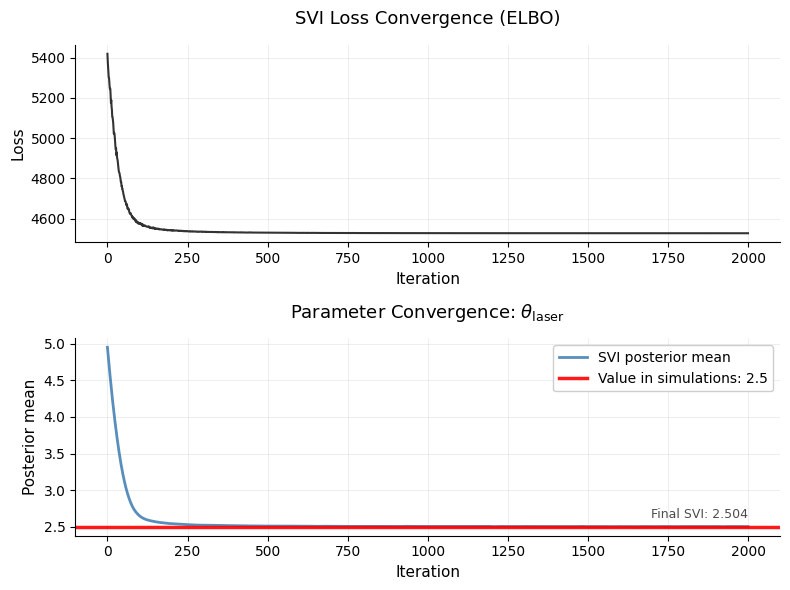

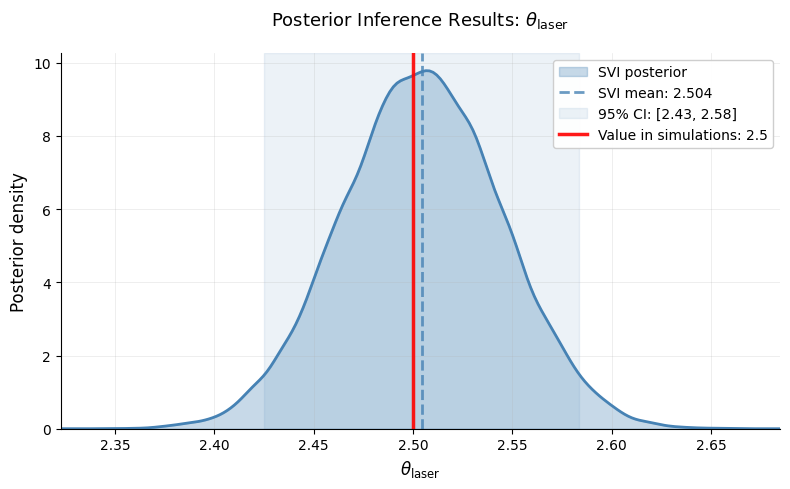


POSTERIOR INFERENCE SUMMARY
Method       Mean     Std      95% CI               Mode    
------------------------------------------------------------
SVI          2.504    0.040    [2.425, 2.583] 2.506   

Normal Distribution Parameters (SVI):
  Mean (μ): 2.504
  Std (σ): 0.041
  Variance (σ²): 0.002

Value in Simulations Comparison:
  Simulation value: 2.500
  SVI error:  0.0044
  Relative error: 0.18%
  Value in 95% CI: Yes


(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Posterior Inference Results: $\\theta_{\\text{laser}}$'}, xlabel='$\\theta_{\\text{laser}}$', ylabel='Posterior density'>)

In [ ]:
plot_svi_convergence_laser(
    svi_losses, svi_means,
    actual_value=2.5,
    param_label=r"$\theta_{\text{laser}}$"
)

plot_posterior_histogram_laser(
    svi_params,
    actual_value=2.5,
    param_label=r"$\theta_{\text{laser}}$"
)

In [ ]:
def sample_many_trajectories_per_episode(episode, obstacles, n_trajectories=10):
    """
    Sample multiple opponent trajectory realizations for a single episode.
    Robot positions are known, opponent positions are sampled.
    """
    trajectories = []

    for _ in range(n_trajectories):
        initial_robot_pos, initial_opponent_pos, _ = episode['states'][0]
        trajectory = [episode['states'][0]]
        current_opponent_pos = initial_opponent_pos

        for i in range(len(episode['states']) - 1):
            robot_pos = episode['states'][i + 1][0]
            terminal = episode['states'][i + 1][2]

            if not terminal:
                current_opponent_pos = apply_stochastic_opponent_movement(
                    robot_pos=robot_pos,
                    prev_opponent_pos=current_opponent_pos,
                    obstacles=obstacles
                )

            trajectory.append((robot_pos, current_opponent_pos, terminal))

        trajectories.append(trajectory)

    return trajectories


def generate_many_trajectories_all_episodes(data, n_trajectories=10):
    """
    Generate N trajectory realizations for each episode.
    """
    obstacles = set(data['obstacles'])
    all_trajectories = []

    for episode in data['episodes']:
        trajectories = sample_many_trajectories_per_episode(episode, obstacles, n_trajectories)
        all_trajectories.append(trajectories)

    return all_trajectories


def model_with_multiple_trajectories(data, all_trajectories):
    """
    LaserTag model using multiple trajectories per episode with logsumexp.
    """
    laser_std = numpyro.sample('laser_std', dist.Exponential(0.2))

    for iepisode, episode in enumerate(data['episodes']):
        trajectories = all_trajectories[iepisode]
        observations = episode['observations']

        logps = []
        for traj in trajectories:
            logp = logprob_laser_episode(laser_std, traj, observations)
            logps.append(logp)

        logps_array = jnp.array(logps)
        episode_logp = logsumexp(logps_array)

        numpyro.factor(f'episode_{iepisode}', episode_logp)

def svi_inference_stochastic_margin_laser(data, n_trajectories=10, num_steps=2000):
    """
    Run SVI with stochastic marginalization for LaserTag.
    """
    print(f"Running SVI with N={n_trajectories} trajectories per episode...")

    optimizer = numpyro.optim.Adam(step_size=0.01)
    svi = SVI(model_with_multiple_trajectories, guide, optimizer,
              loss=Trace_ELBO(num_particles=1000))

    rng_key = jax.random.PRNGKey(int(time.time() * 1E6))

    init_trajs = generate_many_trajectories_all_episodes(data, n_trajectories)
    svi_state = svi.init(rng_key, data, init_trajs)

    losses0 = jnp.zeros(num_steps)
    means0 = jnp.zeros(num_steps)
    sds0 = jnp.zeros(num_steps)

    def body_fn(i, carry):
        svi_state, losses, means, sds = carry

        all_trajectories = generate_many_trajectories_all_episodes(data, n_trajectories)
        svi_state, loss = svi.update(svi_state, data, all_trajectories)

        params = svi.get_params(svi_state)
        mean_val = params['laser_std_mean']
        sd_val = params['laser_std_std']

        losses = losses.at[i].set(loss)
        means = means.at[i].set(mean_val)
        sds = sds.at[i].set(sd_val)

        return svi_state, losses, means, sds

    svi_state, losses, means, sds = jax.lax.fori_loop(
        0, num_steps, body_fn, (svi_state, losses0, means0, sds0))

    params = svi.get_params(svi_state)
    return list(np.array(losses)), list(np.array(means)), list(np.array(sds)), params

In [ ]:
K_VALUES = [1, 5, 10, 20, 50]
N_RUNS = 10
NUM_STEPS = 750

results = load_data('wasserstein_results', subdir='experiments') or {}
if results:
    print(f"Found results for N values: {list(results.keys())}")

for n in K_VALUES:
    distances = results.get(n, {}).get('distances', [])
    means = results.get(n, {}).get('svi_means', [])

    if len(distances) >= N_RUNS:
        print(f"\nK={n}: Complete ({len(distances)}/{N_RUNS})")
        continue

    print(f"\nK={n}: {'Resuming' if distances else 'Starting'} ({len(distances)}/{N_RUNS})")

    attempts = 0
    max_attempts = 5

    while len(distances) < N_RUNS and attempts < max_attempts:
        print(f"  Run {len(distances)+1}/{N_RUNS} (attempt {attempts})...", end=" ")

        _, _, _, params = svi_inference_stochastic_margin_laser(
            lasertag_data_unobserved_opponent, n_trajectories=n, num_steps=NUM_STEPS
        )

        svi_mean = float(params['laser_std_mean'])
        svi_std = float(params['laser_std_std'])

        if np.isnan(svi_mean) or np.isnan(svi_std):
            print(f"NaN detected, retrying...")
            print(f"    Parameters:")
            for key, value in params.items():
                print(f"      {key}: {value}")
            attempts += 1
            continue
        else:
            attempts = 0

        svi_samples = np.random.normal(svi_mean, svi_std, size=len(mcmc_laser_std_samples))
        distance = wasserstein_distance(mcmc_laser_std_samples, svi_samples)

        distances.append(distance)
        means.append(svi_mean)
        print(f"distance = {distance:.4f}, mean = {svi_mean:.4f}")

        results[n] = {
            'distances': distances,
            'mean_distance': np.mean(distances),
            'std_distance': np.std(distances),
            'svi_means': means,
            'mean_svi_mean': np.mean(means),
            'completed_runs': len(distances),
            'total_runs': N_RUNS
        }
        save_data('wasserstein_results', results, subdir='experiments', show_prints=False)

    if len(distances) < N_RUNS:
        print(f"  WARNING: Only got {len(distances)}/{N_RUNS} valid runs after {attempts} attempts")

    r = results[n]
    print(f"  Summary: Wasserstein = {r['mean_distance']:.4f}+/-{r['std_distance']:.4f}, SVI mean = {r['mean_svi_mean']:.4f}")

print(f"\n{'='*60}")
print("BIAS REDUCTION SUMMARY")
print(f"{'='*60}")
print(f"{'K':<10} {'Mean Dist':<15} {'Std Dist':<15} {'Runs':<10}")
print("-" * 60)
for n in K_VALUES:
    if n in results:
        r = results[n]
        print(f"{n:<10} {r['mean_distance']:<15.4f} {r['std_distance']:<15.4f} {r['completed_runs']}/{r['total_runs']:<10}")
print(f"{'='*60}")

Loaded: wasserstein_results
Found results for N values: [1, 5, 10, 20, 50]

K=1: Complete (10/10)

K=5: Complete (10/10)

K=10: Complete (10/10)

K=20: Complete (10/10)

K=50: Complete (10/10)

BIAS REDUCTION SUMMARY
K          Mean Dist       Std Dist        Runs      
------------------------------------------------------------
1          0.3026          0.6471          10/10        
5          0.0437          0.0061          10/10        
10         0.0502          0.0273          10/10        
20         0.0560          0.0345          10/10        
50         0.0366          0.0041          10/10        


In [ ]:
def plot_wasserstein_results(results):
    """
    Plot Wasserstein distance vs K with error bars.
    """
    n_values = sorted(results.keys())
    mean_distances = [results[n]['mean_distance'] for n in n_values]
    std_distances = [results[n]['std_distance'] for n in n_values]

    plt.style.use('default')
    fig, ax = plt.subplots(figsize=(8, 6))

    ax.errorbar(n_values, mean_distances, yerr=std_distances,
                marker='o', linewidth=2, capsize=5, capthick=2,
                color='steelblue', ecolor='steelblue', alpha=0.8)

    # Add text annotations above each point
    for n, mean, std in zip(n_values, mean_distances, std_distances):
        ax.text(n, mean + std + 0.005, f'{mean:.3f}\n±{std:.3f}',
                ha='center', va='bottom', fontsize=9, alpha=0.7)

    ax.set_xlabel('Number of trajectories (K)', fontsize=12)
    ax.set_ylabel('Wasserstein Distance', fontsize=12)
    ax.set_title('Bias Reduction: SVI vs MCMC (Known Positions)', fontsize=13, pad=15)
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.text(0.95, 0.95, f'Lower is better\n(closer to MCMC)',
            transform=ax.transAxes, fontsize=10,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

    plt.tight_layout()
    plt.show()

    return fig, ax

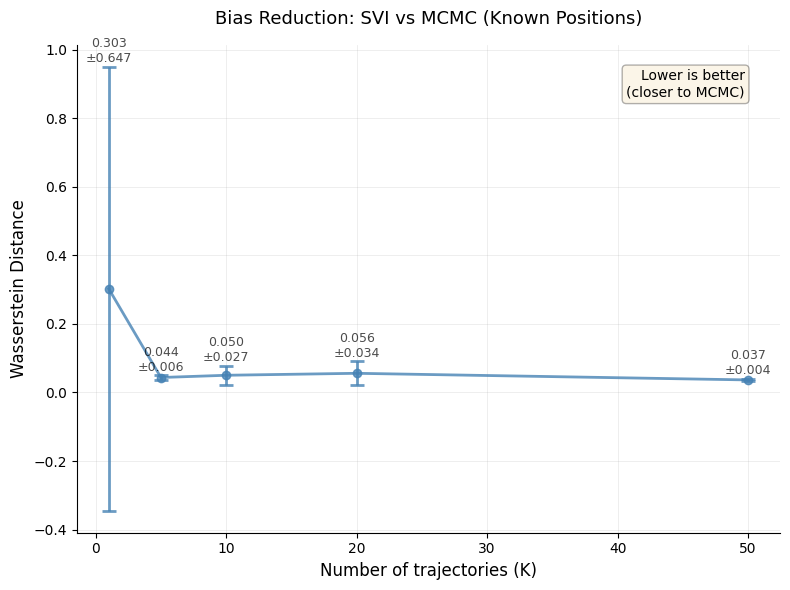

(<Figure size 800x600 with 1 Axes>,
 <Axes: title={'center': 'Bias Reduction: SVI vs MCMC (Known Positions)'}, xlabel='Number of trajectories (K)', ylabel='Wasserstein Distance'>)

In [ ]:
plot_wasserstein_results(results)